# 🎬 Netflix Content Analysis — How Netflix Conquered the World

**Course:** Data Analysis and Presentation with Python  
**Faculty of Engineering — AIE Program — Mansoura National University**  
**Spring Semester 2026**

---

## 📌 Project Overview
This project analyzes the complete Netflix Movies & TV Shows catalog to uncover how the world's biggest streaming platform has grown, what kind of content it produces, and how its strategy has changed over time.

## 🎯 Objectives
1. **Clean** the raw Netflix dataset (handle missing values, parse dates, split multi-value columns)
2. **Engineer** new features (year added, month added, main country, duration in minutes)
3. **Explore** the data with descriptive statistics
4. **Visualize** insights with **6 different chart types**
5. **Tell a story** about Netflix's global expansion

## 🛠️ Tools Used
- `pandas` — data processing
- `numpy` — numerical operations
- `matplotlib` & `seaborn` — visualization

## 📂 Dataset
- **Source:** [Kaggle — Netflix Movies & TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows)
- **Size:** ~8,800 titles, 12 columns
- **Columns:** show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description

## 1. Import Libraries and Load the Data

In [ ]:
# Import all the libraries we will use
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotly for interactive charts
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Make plots look nice
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Suppress warnings for a cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully ✓")

Libraries imported successfully ✓


In [ ]:
# Load the Netflix dataset
# Note: change this path if your CSV is in a different location
df = pd.read_csv("netflix_titles.csv")

# Show the first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 2. Understand the Data

Before cleaning, let's see what we're working with.

In [ ]:
# Shape of the dataset (rows, columns)
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")
print()

# Show data types and non-null counts
df.info()

Dataset has 8807 rows and 12 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
# How many movies vs TV shows?
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


**What we notice:**
- The dataset has around **8,800 titles** with both Movies and TV Shows.
- Several columns have missing values: especially `director`, `cast`, `country`, and `date_added`.
- The `date_added` column is text and needs to be converted to a datetime.
- `country` and `listed_in` (genres) sometimes contain multiple values separated by commas.
- `duration` is text mixing "min" (for movies) and "Seasons" (for TV shows).

## 3. Data Cleaning

### 3.1 Check Missing Values

In [ ]:
# Show how many missing values are in each column
missing = df.isnull().sum()
missing_percent = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})
missing_summary[missing_summary['Missing Count'] > 0]

,Missing Count,Missing %
director,2634,29.91
cast,825,9.37
country,831,9.44
date_added,10,0.11
rating,4,0.05
duration,3,0.03


### 3.2 Fill Missing Values

We use **smart defaults** instead of dropping rows (which would lose data):
- `director` → `'Unknown'` (many titles legitimately have no listed director)
- `cast` → `'Unknown'`
- `country` → `'Unknown'`
- `rating` → `'Not Rated'`
- We drop rows where `date_added` is missing (only a few)

In [ ]:
# Fill missing categorical values with sensible defaults
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

# Drop rows where date_added is missing (we need this for time analysis)
df = df.dropna(subset=['date_added'])

# Confirm no more missing values in key columns
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64


### 3.3 Convert Date Column to Datetime

In [ ]:
# Convert 'date_added' from text to a real datetime object
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Drop rows where the conversion failed
df = df.dropna(subset=['date_added'])

# Now we can extract year and month
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print(f"Date range: {df['date_added'].min().date()} to {df['date_added'].max().date()}")
df[['title', 'date_added', 'year_added', 'month_added']].head()

Date range: 2008-01-01 to 2021-09-25


,title,date_added,year_added,month_added
0,Dick Johnson Is Dead,2021-09-25,2021,9
1,Blood & Water,2021-09-24,2021,9
2,Ganglands,2021-09-24,2021,9
3,Jailbirds New Orleans,2021-09-24,2021,9
4,Kota Factory,2021-09-24,2021,9


### 3.4 Check for Duplicates

In [ ]:
# Check and remove any duplicate rows
print(f"Number of duplicates: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicates: 0
Shape after removing duplicates: (8709, 14)


## 4. Feature Engineering

We will create **3 useful new columns** to make analysis easier:

| New Feature | How We Build It |
|---|---|
| `main_country` | First country listed (some titles list multiple countries) |
| `duration_num` | Just the number from `duration` (e.g. "90 min" → 90) |
| `main_genre` | First genre listed in `listed_in` |

In [ ]:
# 1. Take only the first country (some rows have multiple separated by commas)
df['main_country'] = df['country'].str.split(',').str[0].str.strip()

# 2. Take only the first genre
df['main_genre'] = df['listed_in'].str.split(',').str[0].str.strip()

# 3. Extract numeric duration (minutes for movies, seasons for TV shows)
def extract_duration(value):
    if pd.isna(value):
        return np.nan
    s = str(value)
    if 'min' in s:
        return float(s.replace(' min', '').strip())
    elif 'Season' in s:
        return float(s.split(' ')[0])
    return np.nan

df['duration_num'] = df['duration'].apply(extract_duration)

df[['title', 'type', 'main_country', 'main_genre', 'duration', 'duration_num']].head()

,title,type,main_country,main_genre,duration,duration_num
0,Dick Johnson Is Dead,Movie,United States,Documentaries,90 min,90.0
1,Blood & Water,TV Show,South Africa,International TV Shows,2 Seasons,2.0
2,Ganglands,TV Show,Unknown,Crime TV Shows,1 Season,1.0
3,Jailbirds New Orleans,TV Show,Unknown,Docuseries,1 Season,1.0
4,Kota Factory,TV Show,India,International TV Shows,2 Seasons,2.0


## 5. Exploratory Data Analysis (EDA)

### 5.1 Descriptive Statistics

In [ ]:
# Summary statistics for numerical columns
df[['release_year', 'year_added', 'duration_num']].describe().round(2)

,release_year,year_added,duration_num
count,8709.00,8709.00,8706.00
mean,2014.20,2018.89,70.59
std,8.83,1.57,50.61
min,1925.00,2008.00,1.00
25%,2013.00,2018.00,3.00
50%,2017.00,2019.00,89.00
75%,2019.00,2020.00,106.00
max,2021.00,2021.00,312.00


### 5.2 How Many Titles per Year?

In [ ]:
# Count of titles added each year
titles_per_year = df.groupby('year_added').size()
print("Titles added per year:")
print(titles_per_year)

Titles added per year:
year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1164
2018    1625
2019    1999
2020    1878
2021    1498
dtype: int64


### 5.3 Egyptian Content on Netflix 🇪🇬

Let's see how much Egyptian content is on Netflix as a local insight.

In [ ]:
# Filter rows where the country contains "Egypt"
egyptian_content = df[df['country'].str.contains('Egypt', case=False, na=False)]
print(f"Number of titles involving Egypt: {len(egyptian_content)}")
print()
print("Movie vs TV Show split:")
print(egyptian_content['type'].value_counts())

Number of titles involving Egypt: 117

Movie vs TV Show split:
type
Movie      102
TV Show     15
Name: count, dtype: int64


## 6. Visualizations to Drive Insights

The assignment requires **at least 4 different charts** — we will create **6 different chart types** to tell a complete story.

### 📊 Chart 1: Movies vs TV Shows (Pie Chart)

What is the split between Movies and TV Shows on Netflix?

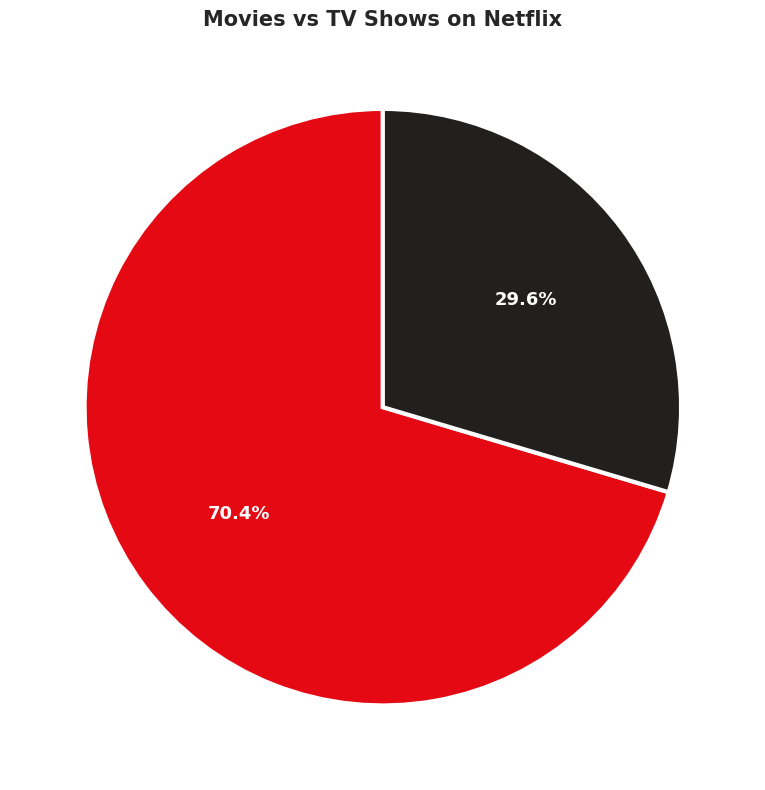


Movies: 6,131 titles
TV Shows: 2,578 titles


In [ ]:
# Count Movies vs TV Shows
type_counts = df['type'].value_counts()

plt.figure(figsize=(8, 8))
colors = ['#E50914', '#221F1F']  # Netflix red & black
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 13, 'color': 'white', 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 3})
plt.title('Movies vs TV Shows on Netflix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nMovies: {type_counts['Movie']:,} titles")
print(f"TV Shows: {type_counts['TV Show']:,} titles")

**Insight 1:** Netflix's catalog is dominated by **Movies** (~70%), with TV Shows making up about a third. This reflects Netflix's origins as a movie rental service before it became a major TV producer.

### 📈 Chart 2: Netflix Content Growth Over Years

How many titles did Netflix add each year? This is the story of Netflix's global expansion.

In [ ]:
yearly_growth = df.groupby(['year_added', 'type']).size().reset_index(name='count')

fig_line = px.line(
    yearly_growth,
    x='year_added',
    y='count',
    color='type',
    markers=True,
    title='📈 Netflix Content Growth Over the Years',
    labels={'year_added': 'Year Added', 'count': 'Number of Titles', 'type': 'Content Type'},
    color_discrete_map={'Movie': '#E50914', 'TV Show': '#b3b3b3'}
)
fig_line.update_traces(
    line_width=3,
    marker_size=8,
    hovertemplate='<b>%{fullData.name}</b><br>Year: %{x}<br>Titles: %{y:,}<extra></extra>'
)
fig_line.update_layout(
    paper_bgcolor='#1a1a1a',
    plot_bgcolor='#1a1a1a',
    font_color='white',
    title_font_size=18,
    xaxis=dict(showgrid=False),
    yaxis=dict(gridcolor='#333'),
    legend=dict(bgcolor='#2a2a2a', bordercolor='#444')
)
fig_line.show()

In [ ]:
fig_line.write_html("netflix_line.html")

**Insight 2:** Netflix added very little content before 2015. Then there was a **massive surge between 2016–2019** as Netflix invested heavily in original content and expanded to ~190 countries. Notice the slight decline after 2020 — likely a combination of pandemic disruption and a more selective strategy.

### 📊 Chart 3: Top 10 Countries Producing Netflix Content (Horizontal Bar Chart)

Which countries dominate Netflix's catalog?

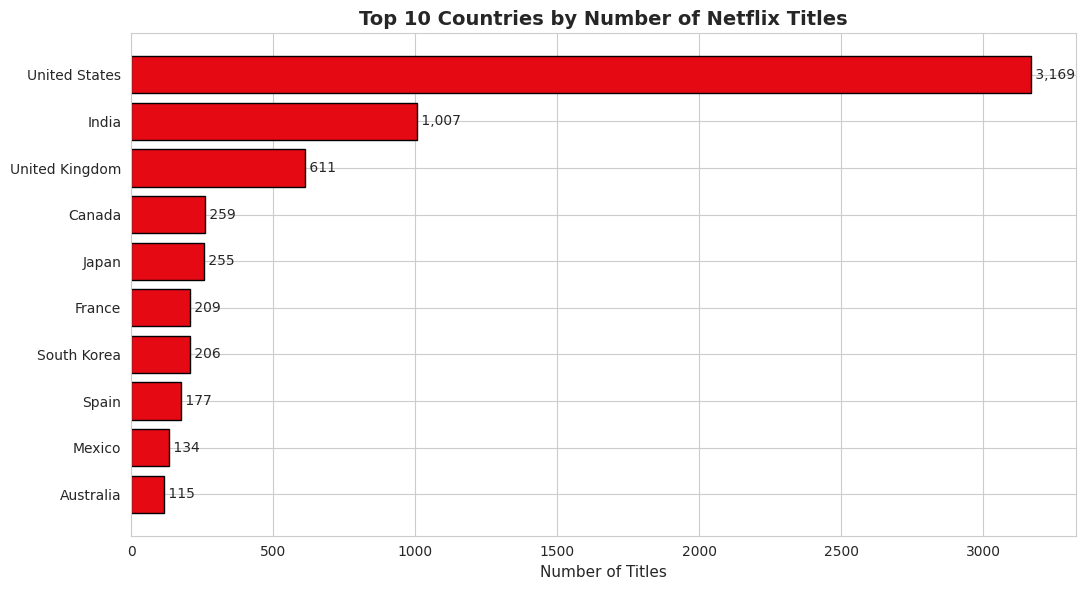

In [ ]:
# Top 10 countries (excluding "Unknown")
top_countries = df[df['main_country'] != 'Unknown']['main_country'].value_counts().head(10)

plt.figure(figsize=(11, 6))
bars = plt.barh(top_countries.index, top_countries.values, color='#E50914', edgecolor='black')
plt.gca().invert_yaxis()  # Highest at the top
plt.title('Top 10 Countries by Number of Netflix Titles', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=11)

# Add value labels on each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f' {int(width):,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Insight 3:** The **United States** dominates with by far the most titles, followed by **India** and the **United Kingdom**. India's strong second place reflects Netflix's heavy investment in Bollywood and regional Indian content. South Korea also shows up strongly thanks to the global popularity of K-dramas.

### 📊 Chart 4: Most Popular Genres (Horizontal Bar Chart)

What kinds of content dominate the platform?

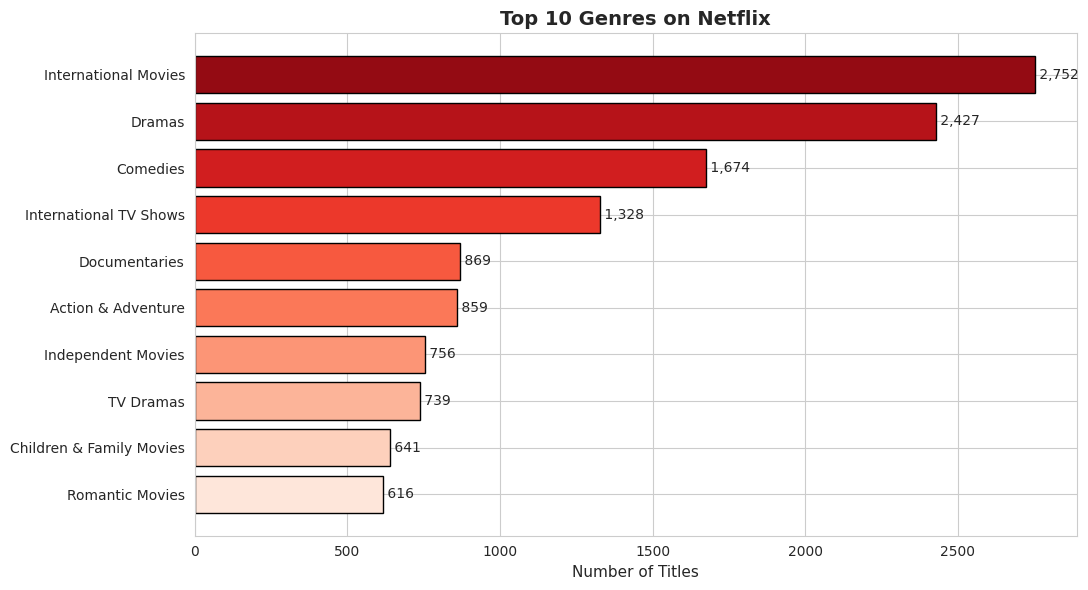

In [ ]:
# Split the listed_in column to count individual genres
all_genres = df['listed_in'].str.split(', ').explode()
top_genres = all_genres.value_counts().head(10)

plt.figure(figsize=(11, 6))
bars = plt.barh(top_genres.index, top_genres.values,
                color=sns.color_palette('Reds_r', n_colors=10), edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top 10 Genres on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=11)

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f' {int(width):,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Insight 4:** **International Movies** and **Dramas** are the largest categories, showing Netflix's strategy of catering to a global audience. Comedies and Documentaries also rank high — these are typically lower-cost to produce and have broad appeal.

### 📊 Chart 5: Movie Duration Distribution (Histogram)

How long is the typical Netflix movie?

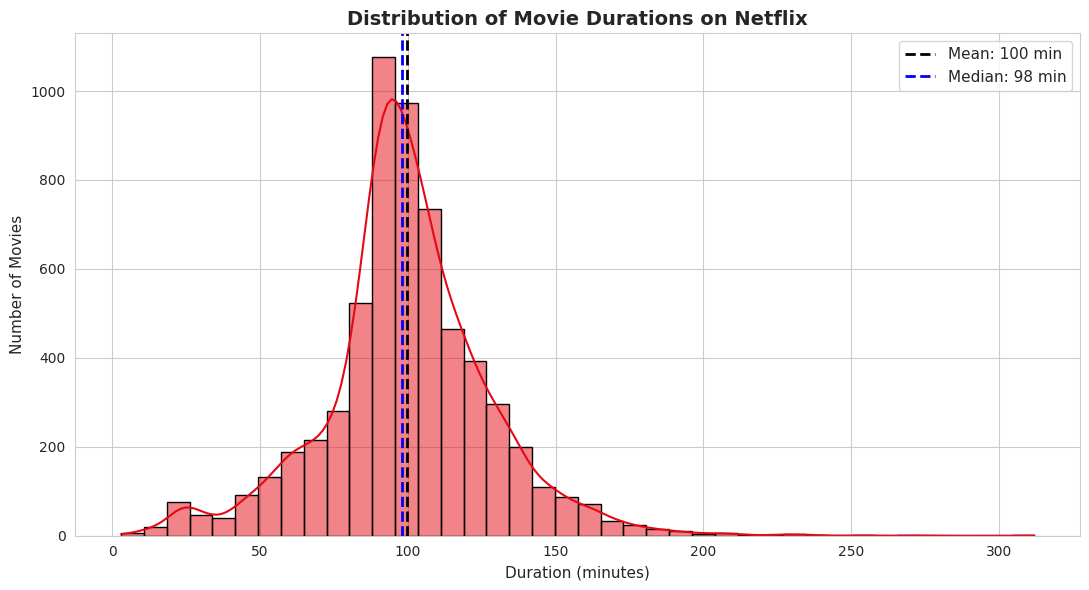


Shortest movie: 3 min
Longest movie: 312 min


In [ ]:
# Get only movies and their durations in minutes
movies = df[df['type'] == 'Movie'].copy()

plt.figure(figsize=(11, 6))
sns.histplot(movies['duration_num'], bins=40, kde=True,
             color='#E50914', edgecolor='black')
plt.axvline(movies['duration_num'].mean(), color='black', linestyle='--',
            linewidth=2, label=f"Mean: {movies['duration_num'].mean():.0f} min")
plt.axvline(movies['duration_num'].median(), color='blue', linestyle='--',
            linewidth=2, label=f"Median: {movies['duration_num'].median():.0f} min")

plt.title('Distribution of Movie Durations on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)', fontsize=11)
plt.ylabel('Number of Movies', fontsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nShortest movie: {movies['duration_num'].min():.0f} min")
print(f"Longest movie: {movies['duration_num'].max():.0f} min")

**Insight 5:** Most Netflix movies are around **90–110 minutes long** — a sweet spot for streaming attention spans. The distribution is fairly normal, with a small tail of very long films (3+ hours) which are often documentaries or international epics.

### 🔥 Chart 6: When Does Netflix Add Content? (Heatmap)

Is there a pattern to which months Netflix releases content? A heatmap reveals it instantly.

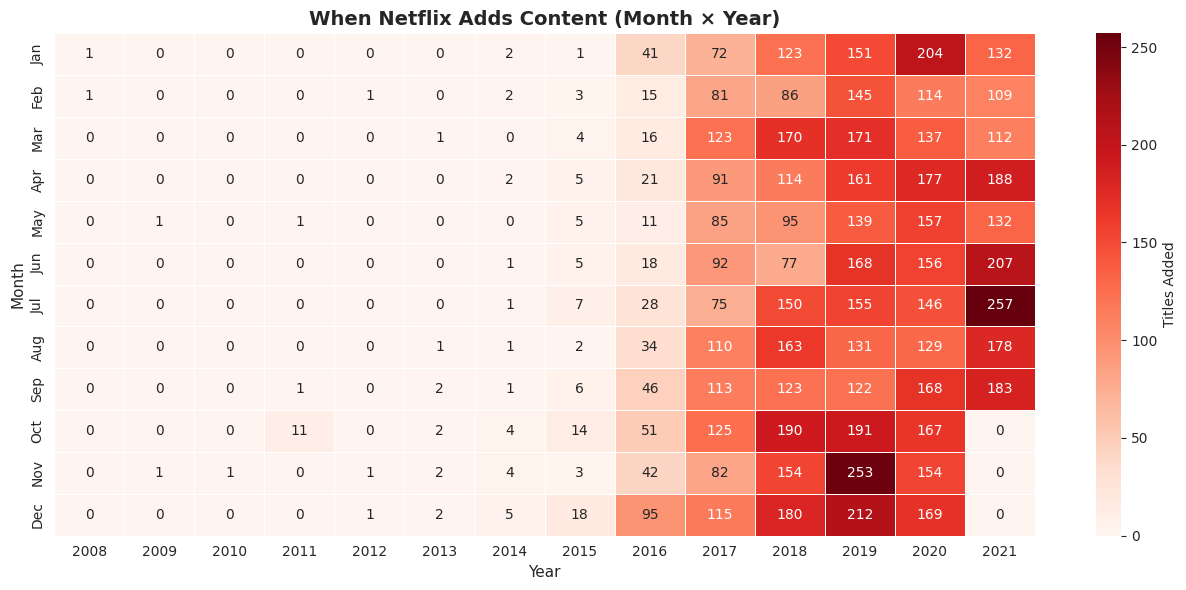

In [ ]:
# Create a pivot table: rows = month, columns = year, values = count
heatmap_data = df.pivot_table(
    index='month_added',
    columns='year_added',
    values='show_id',
    aggfunc='count',
    fill_value=0
)

# Rename month numbers to month names for readability
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_data.index = [month_names[i-1] for i in heatmap_data.index]

plt.figure(figsize=(13, 6))
sns.heatmap(heatmap_data, cmap='Reds', annot=True, fmt='d',
            linewidths=0.5, cbar_kws={'label': 'Titles Added'})
plt.title('When Netflix Adds Content (Month × Year)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Month', fontsize=11)
plt.tight_layout()
plt.show()

**Insight 6:** Netflix tends to add **more content at the end of the year** (October–January), likely targeting holiday-season viewing. The most active years (brightest cells) are 2018–2020, confirming what we saw in the line chart — Netflix's golden era of expansion.

### 🔥 Chart 7 🌐 Interactive Choropleth Map — Netflix Content by Country

In [ ]:
country_counts = (
    df[df['main_country'] != 'Unknown']
    ['main_country'].value_counts()
    .reset_index()
)
country_counts.columns = ['country', 'count']

fig_map = px.choropleth(
    country_counts,
    locations='country',
    locationmode='country names',
    color='count',
    color_continuous_scale='Reds',
    title='🌐 Netflix Content Distribution by Country',
    labels={'count': 'Number of Titles'},
    hover_name='country',
    hover_data={'count': True}
)
fig_map.update_layout(
    paper_bgcolor='#1a1a1a',
    geo=dict(
        bgcolor='#1a1a1a',
        landcolor='#2a2a2a',
        showcoastlines=True,
        coastlinecolor='#444',
        showocean=True,
        oceancolor='#0d0d0d',
        showframe=False
    ),
    font_color='white',
    title_font_size=18,
    coloraxis_colorbar=dict(tickfont=dict(color='white'), title=dict(font=dict(color='white')))
)
fig_map.show()

In [ ]:
fig_map.write_html("netflix_map.html")

## 8. Summary of Key Insights

After cleaning, transforming, and analyzing 8,800+ Netflix titles, our main findings are:

1. **Movies dominate the catalog** (~70%), but Netflix has heavily invested in TV shows since 2016.

2. **2018–2019 was Netflix's peak expansion period** — the platform added more content in those two years than in all the years before combined.

3. **The US, India, and UK are the top 3 content producers**, with India's strong showing reflecting Netflix's massive investment in regional content.

4. **International Movies and Dramas are the most common genres**, showing Netflix's strategy of producing globally-appealing content.

5. **The typical Netflix movie is ~90–110 minutes long** — fitting comfortably into a single evening.

6. **Netflix adds more content during the holiday season** (October–January), aligned with peak viewing times.

7. **Egyptian content is present but limited** — there's a clear opportunity for more MENA-region content as Netflix expands.

## 7.1 Recommendations

- **For Netflix:** Continue investing in international content, especially from underrepresented regions like the Middle East and Africa.
- **For viewers:** Early winter is the best time to discover new releases.
- **For content creators:** Dramas and International Movies are the most-produced categories, suggesting strong demand.

---

### 👥 Project Members
- *Mohmed Ali Ali Shatla <--------  team Leader*
- *Mohamed Osama Kamel*
- *Ibrahim Mohamed Mohamed Amin*
- *Mahmoud ashraf hosny el lakany*
- *Badr Islam ibrahim elewa*
- *Mohamed Ashraf Fawzi Al-Danin*
- *Mohamed Sherif Bahi Jabal*

### 🔗 GitHub Repository
- *(Add your public GitHub repo link here)*

### 📂 Dataset Source
[Kaggle — Netflix Movies & TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows)